In [3]:
import pandas as pd


In [4]:
df = pd.read_csv("loan_data.csv")


In [5]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [7]:
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])


In [8]:
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())


In [9]:
df.isnull().sum()


Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])


In [11]:
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])


In [12]:
df.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [13]:
df["Loan_Status"].value_counts()


Loan_Status
Y    271
N    110
Name: count, dtype: int64

In [14]:
df.groupby("Loan_Status")["ApplicantIncome"].mean()


Loan_Status
N    3602.472727
Y    3570.660517
Name: ApplicantIncome, dtype: float64

In [15]:
df.groupby("Loan_Status")["ApplicantIncome"].describe()


,count,mean,std,min,25%,50%,75%,max
Loan_Status,,,,,,,,
N,110.0,3602.472727,1373.652746,150.0,2647.0,3418.0,4524.5,7660.0
Y,271.0,3570.660517,1440.521280,210.0,2583.0,3276.0,4177.0,9703.0


In [16]:
pd.crosstab(df["Credit_History"], df["Loan_Status"])


Loan_Status,N,Y
Credit_History,,
0.0,54,3
1.0,56,268


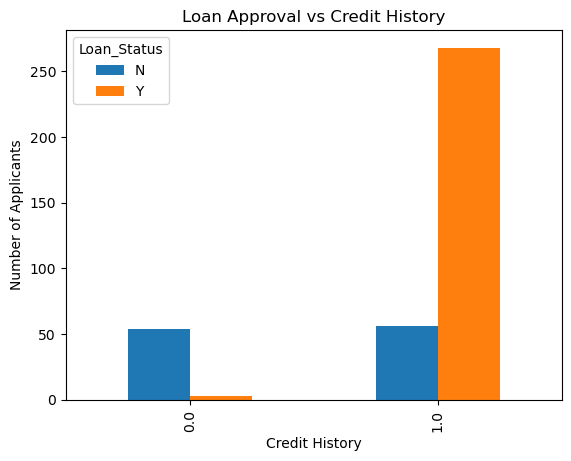

In [17]:
import matplotlib.pyplot as plt

pd.crosstab(df["Credit_History"], df["Loan_Status"]).plot(kind="bar")
plt.title("Loan Approval vs Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")

plt.savefig("credit_history_vs_loan_status.png")
plt.show()


In [18]:
pd.crosstab(df["Property_Area"], df["Loan_Status"])


Loan_Status,N,Y
Property_Area,,
Rural,41,65
Semiurban,30,119
Urban,39,87


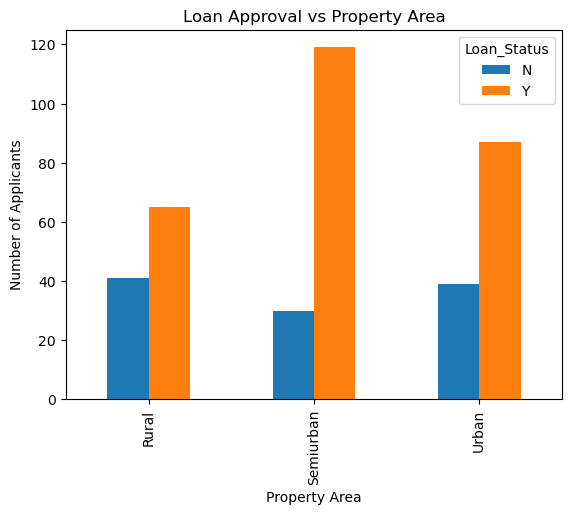

In [25]:
pd.crosstab(df["Property_Area"], df["Loan_Status"]).plot(kind="bar")
plt.title("Loan Approval vs Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")

plt.savefig("property_area_vs_loan_status.png")
plt.show()


In [20]:
median_income = df["ApplicantIncome"].median()
median_income


3333.0

In [21]:
import numpy as np

df["Risk_Level"] = np.where(
    df["Credit_History"] == 0,
    "High Risk",
    np.where(
        (df["ApplicantIncome"] >= median_income) &
        (df["Property_Area"].isin(["Semiurban", "Urban"])),
        "Low Risk",
        "Medium Risk"
    )
)


In [22]:
df["Risk_Level"].value_counts()


Risk_Level
Medium Risk    208
Low Risk       116
High Risk       57
Name: count, dtype: int64

In [23]:
pd.crosstab(df["Risk_Level"], df["Loan_Status"])


Loan_Status,N,Y
Risk_Level,,
High Risk,54,3
Low Risk,20,96
Medium Risk,36,172


In [24]:
df.to_csv("bank_loan_final.csv", index=False)
